# Regression and Prediction

## The Regression Equation - Quick Revision

---

# Purpose of Linear Regression

Simple Linear Regression estimates **how the response variable (Y) changes when the predictor variable (X) changes.**

Unlike correlation, regression has a **direction**:

**Predictor (X) → Response (Y)**

---

# Regression Equation

$$
\hat{Y} = b_0 + b_1X
$$

Where:

* **Ŷ** = Predicted value (Fitted Value)
* **b₀** = Intercept
* **b₁** = Regression Coefficient (Slope)
* **X** = Predictor (Independent Variable)

---

# Meaning of Each Term

### Ŷ (Y-hat)

* Predicted value of Y.
* Produced by the regression model.

### Intercept (b₀)

* Predicted value of Y when **X = 0**.
* Represents the starting point of the regression line.

### Regression Coefficient (b₁)

* Change in the predicted value of Y for every **1-unit increase** in X.
* Positive coefficient → Y increases with X.
* Negative coefficient → Y decreases with X.

---

# Correlation vs Regression

### Correlation

* Measures association between two variables.
* X and Y are interchangeable.
* Does not make predictions.

### Regression

* Predicts Y using X.
* X and Y have specific roles.
* Produces a prediction equation.

---

# Cotton Dust Example

**Predictor (X):** Exposure (Years of cotton dust exposure)

**Response (Y):** PEFR (Lung Capacity)

Regression Equation:

**PEFR = b₀ + b₁ × Exposure**

Interpretation:

* **Intercept (424.583):** Predicted PEFR for a worker with **0 years** of exposure.
* **Coefficient (-4.185):** Each additional year of exposure reduces the predicted PEFR by approximately **4.185 units**.

---

# Visual Understanding

Refer to the textbook figures:

* **Figure 4-1:** Scatter plot showing the relationship between Exposure and PEFR.
* **Figure 4-2:** Best-fit regression line with the learned intercept and slope.

Always study the figures alongside the theory to build intuition.

---

# Jupyter Practice Checklist

After learning the theory:

* Create a simple dataset.
* Separate Predictor (X) and Response (Y).
* Train a Linear Regression model.
* Observe the learned **Intercept** and **Coefficient**.
* Generate **Predicted (Fitted) Values**.
* Calculate **Residuals (Actual − Predicted)**.
* Plot the scatter plot and regression line.
* Modify the dataset and observe how the regression line changes.

---

# Key Takeaways

* Regression learns a mathematical relationship between **X** and **Y**.
* The regression equation predicts **Ŷ**, not the actual **Y**.
* The **Intercept** is the prediction when **X = 0**.
* The **Regression Coefficient** measures how much **Y changes** for every one-unit increase in **X**.
* Positive slope indicates a positive relationship; negative slope indicates an inverse relationship.
* `fit()` learns the **best-fit line** using the **Least Squares** method.
* Visualization is essential for developing intuition before moving on to residual analysis and regression diagnostics.


In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.linear_model import LinearRegression
import seaborn as sns 
np.random.seed(42)

In [3]:
# Generate 100 students studying anywhere from 0.5 to 12 hours
hours = np.random.uniform(0.5, 12, 100).round(1)

# True relation: ~6.5 marks gained per hour, baseline ~30, plus random variation
marks = 30 + (6.5 * hours) + np.random.normal(0, 8, 100)

# Clip marks between 0 and 100 percentage range
marks = np.clip(marks, 0, 100).round(1)

# Create DataFrame
df = pd.DataFrame({"Hours": hours, "Marks": marks})
df.head(10)

,Hours,Marks
0,4.8,61.9
1,11.4,100.0
2,8.9,88.6
3,7.4,62.2
4,2.3,43.2
5,2.3,47.8
6,1.2,49.6
7,10.5,94.1
8,7.4,71.6
9,8.6,81.9


In [4]:
x = df[["Hours"]] # Double bracket returns a dataframe
y = df["Marks"] # Single bracket returns a series

In [5]:
model = LinearRegression()

In [6]:
model.fit(x, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[5.89]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Hours']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,32.95
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [8]:
print(model.intercept_) # bo, y intercept

32.94704730497235


In [9]:
print(model.coef_) # Coefficient (Slope)

[5.89076252]


In [10]:
# Our equation becomes Y(cap) = 8.17x + 33.72

In [11]:
predictions = model.predict(x) 
predictions
df["predictions"] = predictions

In [12]:
df 

,Hours,Marks,predictions
0,4.8,61.9,61.222707
1,11.4,100.0,100.101740
2,8.9,88.6,85.374834
3,7.4,62.2,76.538690
4,2.3,43.2,46.495801
...,...,...,...
95,6.2,63.8,69.469775
96,6.5,71.6,71.237004
97,5.4,67.8,64.757165
98,0.8,37.4,37.659657


In [13]:
df["Residual"] = df["Marks"] - df["predictions"]

In [14]:
df 

,Hours,Marks,predictions,Residual
0,4.8,61.9,61.222707,0.677293
1,11.4,100.0,100.101740,-0.101740
2,8.9,88.6,85.374834,3.225166
3,7.4,62.2,76.538690,-14.338690
4,2.3,43.2,46.495801,-3.295801
...,...,...,...,...
95,6.2,63.8,69.469775,-5.669775
96,6.5,71.6,71.237004,0.362996
97,5.4,67.8,64.757165,3.042835
98,0.8,37.4,37.659657,-0.259657


# Visualise

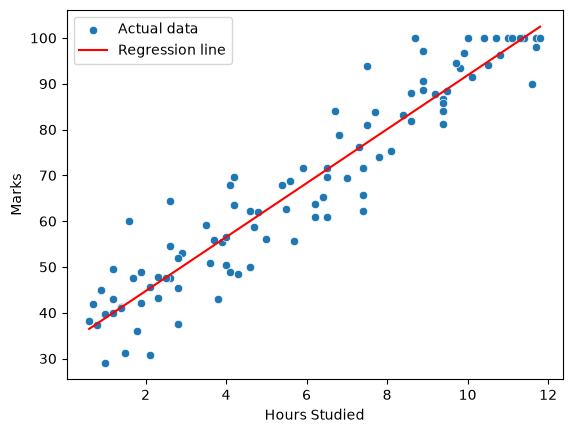

In [15]:
sns.scatterplot(
    data = df,
    x = "Hours",
    y = "Marks",
    label = "Actual data"
)

sns.lineplot(
    data = df,
    x = "Hours",
    y = predictions,
    color = "Red",
    label = "Regression line"
)

plt.xlabel("Hours Studied")
plt.ylabel("Marks")

plt.legend()

plt.show()